In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import matplotlib.pyplot as plt
import requests
import zipfile
from pathlib import Path
import requests
import zipfile



## LBSM

It provides a snapshot of all London’s buildings (both domestic and non-domestic) with information on their energy performance certificates as of 2017.

Please note that the data extracts are based on Ordnance Survey's list of London properties as of 2023. However, as the London Building Stock Model data is from 2017, some of the properties might not have any London Building Stock Model data attached to them.

In [35]:
def download_london_data(url, output_dir=None):
    """
    Download and extract London Borough data from the London Datastore
    
    Parameters:
    url (str): The URL to the ZIP file
    output_dir (str): Directory to save the extracted files (optional)
    
    Returns:
    str: Path to the directory containing extracted files
    """
    
    # Set default output directory
    if output_dir is None:
        output_dir = os.path.join(os.getcwd(), 'london_data')
    
    # Create output directory if it doesn't exist
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    print(f"📥 Downloading data from: {url}")
    
    try:
        # Download the file
        response = requests.get(url, stream=True)
        response.raise_for_status()
        
        # Get the filename from the URL
        filename = url.split('/')[-1]
        zip_path = os.path.join(output_dir, filename)
        
        # Save the ZIP file
        with open(zip_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        
        print(f"✅ Downloaded: {filename} ({os.path.getsize(zip_path) / 1024 / 1024:.1f} MB)")
        
        # Extract the ZIP file
        print(f"📂 Extracting files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(output_dir)
            extracted_files = zip_ref.namelist()
        
        print(f"✅ Extracted {len(extracted_files)} files to: {output_dir}")
        
        # List extracted files
        print(f"\n📄 Extracted files:")
        for file in extracted_files:
            file_path = os.path.join(output_dir, file)
            if os.path.exists(file_path):
                size_mb = os.path.getsize(file_path) / 1024 / 1024
                print(f"   • {file} ({size_mb:.1f} MB)")
        
        # Clean up the ZIP file (optional)
        os.remove(zip_path)
        print(f"\n🗑️  Cleaned up ZIP file: {filename}")
        
        return output_dir
        
    except requests.RequestException as e:
        print(f"❌ Error downloading file: {e}")
        return None
    except zipfile.BadZipFile as e:
        print(f"❌ Error extracting ZIP file: {e}")
        return None
    except Exception as e:
        print(f"❌ Unexpected error: {e}")
        return None

# London Datastore URL for LBSM All London data
london_data_url = "https://data.london.gov.uk/download/14a9f1aa-800b-43a4-ac89-1cd32723286b/5a64fc2f-e3c4-4a63-a495-a3030e1d092d/LBSM_All_London.zip"

# Download and extract the data
data_directory = download_london_data(london_data_url)

📥 Downloading data from: https://data.london.gov.uk/download/14a9f1aa-800b-43a4-ac89-1cd32723286b/5a64fc2f-e3c4-4a63-a495-a3030e1d092d/LBSM_All_London.zip
✅ Downloaded: LBSM_All_London.zip (112.7 MB)
📂 Extracting files...
✅ Downloaded: LBSM_All_London.zip (112.7 MB)
📂 Extracting files...
✅ Extracted 1 files to: /Users/user1/Documents/recoding_adress_data_2011_2021/london_data

📄 Extracted files:
   • LBSM_All_London.csv (1169.9 MB)

🗑️  Cleaned up ZIP file: LBSM_All_London.zip
✅ Extracted 1 files to: /Users/user1/Documents/recoding_adress_data_2011_2021/london_data

📄 Extracted files:
   • LBSM_All_London.csv (1169.9 MB)

🗑️  Cleaned up ZIP file: LBSM_All_London.zip


In [36]:
# List files and their sizes in the data directory
for root, dirs, files in os.walk(data_directory):
    for file in files:
        file_path = os.path.join(root, file)
        size_mb = os.path.getsize(file_path) / 1024 / 1024
        print(f"{file_path} - {size_mb:.2f} MB")

/Users/user1/Documents/recoding_adress_data_2011_2021/london_data/.DS_Store - 0.01 MB
/Users/user1/Documents/recoding_adress_data_2011_2021/london_data/oa_adress_counts.csv - 48.12 MB
/Users/user1/Documents/recoding_adress_data_2011_2021/london_data/oa_and_ward_address_counts.csv - 49.65 MB
/Users/user1/Documents/recoding_adress_data_2011_2021/london_data/LBSM_All_London.csv - 1169.91 MB
/Users/user1/Documents/recoding_adress_data_2011_2021/london_data/adress_data_shps_unzipped/AdressBasePremium_residential_address_2019-06-30.cpg - 0.00 MB
/Users/user1/Documents/recoding_adress_data_2011_2021/london_data/adress_data_shps_unzipped/AdressBasePremium_residential_address_2014-06-30.shx - 27.60 MB
/Users/user1/Documents/recoding_adress_data_2011_2021/london_data/adress_data_shps_unzipped/AdressBasePremium_residential_address_2019-06-30.shp - 102.32 MB
/Users/user1/Documents/recoding_adress_data_2011_2021/london_data/adress_data_shps_unzipped/AdressBasePremium_residential_address_2013-06-30.

In [37]:
# Read the CSV file into a DataFrame
file_path = '/Users/user1/Documents/recoding_adress_data_2011_2021/london_data/LBSM_All_London.csv'
lbsm_all_data_df = pd.read_csv(file_path)
print(lbsm_all_data_df.info())
print(lbsm_all_data_df.head())

/var/folders/k7/sydv9mbx0kz7fx7373rx_2100000gp/T/ipykernel_77266/1626094293.py:3: DtypeWarning: Columns (22,23,26,28,32,34,36,38,40,42) have mixed types. Specify dtype option on import or set low_memory=False.
  lbsm_all_data_df = pd.read_csv(file_path)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4710943 entries, 0 to 4710942
Data columns (total 43 columns):
 #   Column                                                Dtype  
---  ------                                                -----  
 0   UPRN                                                  int64  
 1   SCU_ID                                                float64
 2   OS_TOPO_TOID                                          object 
 3   EASTING                                               float64
 4   NORTHING                                              float64
 5   LATITUDE                                              float64
 6   LONGITUDE                                             float64
 7   OA                                                    object 
 8   LSOA                                                  object 
 9   MSOA                                                  object 
 10  OAC                                                   object 
 11  WARD_CODE  

In [38]:
LBSM_All_London = '/Users/user1/Documents/recoding_adress_data_2011_2021/london_data/LBSM_All_London.csv'
oa_and_ward_address = '/Users/user1/Documents/recoding_adress_data_2011_2021/london_data/oa_and_ward_address_counts.csv'
#read the CSV file into a DataFrame
lbsm_all_data_df = pd.read_csv(LBSM_All_London)
oa_and_ward_address = pd.read_csv(oa_and_ward_address)

/var/folders/k7/sydv9mbx0kz7fx7373rx_2100000gp/T/ipykernel_77266/2532413760.py:4: DtypeWarning: Columns (22,23,26,28,32,34,36,38,40,42) have mixed types. Specify dtype option on import or set low_memory=False.
  lbsm_all_data_df = pd.read_csv(LBSM_All_London)


In [39]:
lbsm_all_data_df

,UPRN,SCU_ID,OS_TOPO_TOID,EASTING,NORTHING,LATITUDE,LONGITUDE,OA,LSOA,MSOA,...,AGG_EPC_CURRENT_ENERGY_EFFICIENCY_BY_FLOORAREA,AGG_EPC_CURRENT_ENERGY_RATING_BY_FLOORAREA,AGG_EPC_POTENTIAL_ENERGY_EFFICIENCY_BY_COUNT,AGG_EPC_POTENTIAL_ENERGY_RATING_BY_COUNT,AGG_EPC_POTENTIAL_ENERGY_EFFICIENCY_BY_FLOORAREA,AGG_EPC_POTENTIAL_ENERGY_RATING_BY_FLOORAREA,AGG_RVEPC_CURRENT_ENERGY_EFFICIENCY_BY_COUNT,AGG_RVEPC_CURRENT_ENERGY_RATING_BY_COUNT,AGG_RVEPC_CURRENT_ENERGY_EFFICIENCY_BY_FLOORAREA,AGG_RVEPC_CURRENT_ENERGY_RATING_BY_FLOORAREA
0,95510923,5.030100e+13,osgb1000005894597,532123.00,182028.00,51.521725,-0.096998,E00000010,E01000003,E02000001,...,NaN,NaN,NaN,NaN,NaN,NaN,54.0,E,NaN,NaN
1,100023615843,5.030100e+13,osgb1000005894597,532115.00,182025.00,51.521700,-0.097115,E00000010,E01000003,E02000001,...,NaN,NaN,NaN,NaN,NaN,NaN,54.0,E,NaN,NaN
2,200000071748,5.030100e+13,osgb1000005894760,532193.00,182074.00,51.522122,-0.095973,E00000012,E01000003,E02000001,...,63.0,D,71.0,C,70.0,C,63.0,D,63.0,D
3,200000071808,5.030100e+13,osgb1000005894760,532193.00,182074.00,51.522122,-0.095973,E00000012,E01000003,E02000001,...,63.0,D,71.0,C,70.0,C,63.0,D,63.0,D
4,200000071807,5.030100e+13,osgb1000005894760,532193.00,182074.00,51.522122,-0.095973,E00000012,E01000003,E02000001,...,63.0,D,71.0,C,70.0,C,63.0,D,63.0,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4710938,10092984018,NaN,osgb5000005209443103,511128.51,185534.95,51.557762,-0.398365,E00012429,E01002497,E02006796,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4710939,6041780,NaN,osgb1000041691013,535996.00,183413.00,51.533252,-0.040674,E00021312,E01004234,E02000866,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4710940,10025698549,NaN,osgb5000005214105008,529149.52,192466.94,51.616224,-0.136000,E00007613,E01001534,E02000308,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4710941,6160138,NaN,osgb5000005267263349,537621.77,179724.87,51.499716,-0.018689,E00167132,E01032772,E02006853,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# Check the column names and basic structure
print("Column names:")
print(lbsm_all_data_df.columns.tolist())
print(f"\nDataFrame shape: {lbsm_all_data_df.shape}")
print(f"\nFirst few rows:")
print(lbsm_all_data_df.head())

Column names:
['UPRN', 'SCU_ID', 'OS_TOPO_TOID', 'EASTING', 'NORTHING', 'LATITUDE', 'LONGITUDE', 'OA', 'LSOA', 'MSOA', 'OAC', 'WARD_CODE', 'WARD', 'ADMINISTRATIVE_AREA', 'ESTIMATED_FLOOR_COUNT', 'ESTIMATE_TOTAL_FLOOR_AREA_ALL', 'SCU_FOOTPRINT', 'MEAN_OBJECT_HEIGHT_M', 'BASEMENT_FLOOR', 'COUNT_D_UPRNS', 'COUNT_ND_UPRNS', 'MIX_CLASS', 'DOMINANT_ND_ACTIVITY_BY_C2_FS', 'DOMINANT_ND_ACTIVITY_BY_C2_COUNT', 'DEC_COUNT', 'AGG_DEC_CURRENT_OPERATIONAL_RATING_BY_COUNT', 'AGG_DEC_CURRENT_OPERATIONAL_RATING_BAND_BY_COUNT', 'AGG_DEC_CURRENT_OPERATIONAL_RATING_BY_FLOORAREA', 'AGG_DEC_CURRENT_OPERATIONAL_RATING_BAND_BY_FLOORAREA', 'EPC_RATING_COUNT_DOM', 'EPC_RATING_COUNT_NONDOM', 'AGG_EPC_CURRENT_ENERGY_EFFICIENCY_BY_COUNT', 'AGG_EPC_CURRENT_ENERGY_RATING_BY_COUNT', 'AGG_EPC_CURRENT_ENERGY_EFFICIENCY_BY_FLOORAREA', 'AGG_EPC_CURRENT_ENERGY_RATING_BY_FLOORAREA', 'AGG_EPC_POTENTIAL_ENERGY_EFFICIENCY_BY_COUNT', 'AGG_EPC_POTENTIAL_ENERGY_RATING_BY_COUNT', 'AGG_EPC_POTENTIAL_ENERGY_EFFICIENCY_BY_FLOORAREA'

In [41]:
# Count number of UPRNs per Output Area (OA)
uprn_per_oa = lbsm_all_data_df.groupby('OA')['UPRN'].count().reset_index()
uprn_per_oa.columns = ['OA', 'UPRN_count']

print(f"Number of unique Output Areas: {len(uprn_per_oa)}")
print(f"Total UPRNs: {uprn_per_oa['UPRN_count'].sum()}")
print(f"Average UPRNs per OA: {uprn_per_oa['UPRN_count'].mean():.2f}")
print(f"Median UPRNs per OA: {uprn_per_oa['UPRN_count'].median():.2f}")
print(f"Min UPRNs per OA: {uprn_per_oa['UPRN_count'].min()}")
print(f"Max UPRNs per OA: {uprn_per_oa['UPRN_count'].max()}")

# Display the first 10 rows
print(f"\nFirst 10 Output Areas with UPRN counts:")
print(uprn_per_oa.head(10))

Number of unique Output Areas: 25133
Total UPRNs: 4706385
Average UPRNs per OA: 187.26
Median UPRNs per OA: 155.00
Min UPRNs per OA: 1
Max UPRNs per OA: 7807

First 10 Output Areas with UPRN counts:
          OA  UPRN_count
0  E00000001         128
1  E00000003         136
2  E00000005          90
3  E00000007         307
4  E00000010         172
5  E00000012         147
6  E00000013         226
7  E00000014          83
8  E00000016           2
9  E00000017         150


In [42]:
uprn_per_oa

,OA,UPRN_count
0,E00000001,128
1,E00000003,136
2,E00000005,90
3,E00000007,307
4,E00000010,172
...,...,...
25128,E00176591,98
25129,E00176592,119
25130,E00176593,162
25131,E00176594,116


In [43]:
oa_and_ward_address
#Select year == 2023
oa_and_ward_address_2023 = oa_and_ward_address[oa_and_ward_address['year'] == 2023]

In [44]:
oa_and_ward_address_2023 = oa_and_ward_address_2023[['OA21CD', 'address_count_oa']]

In [45]:
oa_and_ward_address_2023 

,OA21CD,address_count_oa
12,E00000001,116
26,E00000003,125
40,E00000005,76
54,E00000007,106
68,E00000010,146
...,...,...
367503,E00190465,599
367517,E00190466,774
367531,E00190467,550
367545,E00190468,171


In [46]:
# Comprehensive comparison between oa_and_ward_address_2023 and uprn_per_oa
print("=== DATASET COMPARISON ===")
print(f"oa_and_ward_address_2023 shape: {oa_and_ward_address_2023.shape}")
print(f"uprn_per_oa shape: {uprn_per_oa.shape}")
print()

print("=== COLUMN COMPARISON ===")
print("oa_and_ward_address_2023 columns:", oa_and_ward_address_2023.columns.tolist())
print("uprn_per_oa columns:", uprn_per_oa.columns.tolist())
print()

print("=== BASIC STATISTICS ===")
print("oa_and_ward_address_2023 - address_count_oa:")
print(oa_and_ward_address_2023['address_count_oa'].describe())
print()
print("uprn_per_oa - UPRN_count:")
print(uprn_per_oa['UPRN_count'].describe())
print()

# Check overlap in OA codes
oa_2023_codes = set(oa_and_ward_address_2023['OA21CD'])
uprn_oa_codes = set(uprn_per_oa['OA'])

print("=== OUTPUT AREA CODE OVERLAP ===")
print(f"Unique OAs in oa_and_ward_address_2023: {len(oa_2023_codes)}")
print(f"Unique OAs in uprn_per_oa: {len(uprn_oa_codes)}")
print(f"Common OAs: {len(oa_2023_codes.intersection(uprn_oa_codes))}")
print(f"OAs only in oa_and_ward_address_2023: {len(oa_2023_codes - uprn_oa_codes)}")
print(f"OAs only in uprn_per_oa: {len(uprn_oa_codes - oa_2023_codes)}")
print()

=== DATASET COMPARISON ===
oa_and_ward_address_2023 shape: (26402, 2)
uprn_per_oa shape: (25133, 2)

=== COLUMN COMPARISON ===
oa_and_ward_address_2023 columns: ['OA21CD', 'address_count_oa']
uprn_per_oa columns: ['OA', 'UPRN_count']

=== BASIC STATISTICS ===
oa_and_ward_address_2023 - address_count_oa:
count    26402.000000
mean       150.808537
std         74.856674
min          1.000000
25%        123.000000
50%        137.000000
75%        158.000000
max       2070.000000
Name: address_count_oa, dtype: float64

uprn_per_oa - UPRN_count:
count    25133.000000
mean       187.259181
std        157.244879
min          1.000000
25%        135.000000
50%        155.000000
75%        192.000000
max       7807.000000
Name: UPRN_count, dtype: float64

=== OUTPUT AREA CODE OVERLAP ===
Unique OAs in oa_and_ward_address_2023: 26363
Unique OAs in uprn_per_oa: 25133
Common OAs: 23907
OAs only in oa_and_ward_address_2023: 2456
OAs only in uprn_per_oa: 1226



In [47]:
# Merge the datasets to compare the count columns directly
# First, standardize the OA column names
oa_2023_renamed = oa_and_ward_address_2023.rename(columns={'OA21CD': 'OA_code'})
uprn_renamed = uprn_per_oa.rename(columns={'OA': 'OA_code'})

# Merge on OA codes
merged_comparison = pd.merge(oa_2023_renamed, uprn_renamed, on='OA_code', how='inner')

print("=== MERGED DATASET ANALYSIS ===")
print(f"Successfully merged records: {len(merged_comparison)}")
print()

# Calculate differences and ratios
merged_comparison['count_difference'] = merged_comparison['UPRN_count'] - merged_comparison['address_count_oa']
merged_comparison['ratio_uprn_to_address'] = merged_comparison['UPRN_count'] / merged_comparison['address_count_oa']

print("=== COUNT DIFFERENCES ===")
print("Difference (UPRN_count - address_count_oa):")
print(merged_comparison['count_difference'].describe())
print()

print("=== RATIO ANALYSIS ===")
print("Ratio (UPRN_count / address_count_oa):")
print(merged_comparison['ratio_uprn_to_address'].describe())
print()

# Show correlation
correlation = merged_comparison['UPRN_count'].corr(merged_comparison['address_count_oa'])
print(f"Correlation between UPRN_count and address_count_oa: {correlation:.4f}")
print()

# Show examples of biggest differences
print("=== OAs WITH LARGEST POSITIVE DIFFERENCES (UPRN > Address) ===")
largest_positive = merged_comparison.nlargest(10, 'count_difference')[['OA_code', 'address_count_oa', 'UPRN_count', 'count_difference', 'ratio_uprn_to_address']]
print(largest_positive)
print()

print("=== OAs WITH LARGEST NEGATIVE DIFFERENCES (Address > UPRN) ===")
largest_negative = merged_comparison.nsmallest(10, 'count_difference')[['OA_code', 'address_count_oa', 'UPRN_count', 'count_difference', 'ratio_uprn_to_address']]
print(largest_negative)
print()

print("=== SAMPLE OF WELL-MATCHED OAs ===")
# Find OAs where the counts are very similar (difference within 5)
well_matched = merged_comparison[abs(merged_comparison['count_difference']) <= 5].head(10)
print(well_matched[['OA_code', 'address_count_oa', 'UPRN_count', 'count_difference', 'ratio_uprn_to_address']])

=== MERGED DATASET ANALYSIS ===
Successfully merged records: 23942

=== COUNT DIFFERENCES ===
Difference (UPRN_count - address_count_oa):
count    23942.000000
mean        27.567079
std         64.986890
min       -986.000000
25%          7.000000
50%         15.000000
75%         32.000000
max       3625.000000
Name: count_difference, dtype: float64

=== RATIO ANALYSIS ===
Ratio (UPRN_count / address_count_oa):
count    23942.000000
mean         1.380176
std          6.506752
min          0.152620
25%          1.050360
50%          1.109375
75%          1.216374
max        500.333333
Name: ratio_uprn_to_address, dtype: float64

Correlation between UPRN_count and address_count_oa: 0.7225

=== OAs WITH LARGEST POSITIVE DIFFERENCES (UPRN > Address) ===
         OA_code  address_count_oa  UPRN_count  count_difference  \
22682  E00166755               512        4137              3625   
23669  E00175196               204        2158              1954   
22601  E00024113               427 

In [55]:
well_matched 

,OA_code,address_count_oa,UPRN_count,count_difference,ratio_uprn_to_address
10,E00000022,110,115,5,1.045455
25,E00000042,145,148,3,1.020690
26,E00000043,124,126,2,1.016129
31,E00000050,150,150,0,1.000000
39,E00000059,118,121,3,1.025424
48,E00000069,177,172,-5,0.971751
49,E00000070,154,158,4,1.025974
50,E00000071,119,120,1,1.008403
53,E00000074,104,105,1,1.009615
55,E00000076,111,114,3,1.027027


/var/folders/k7/sydv9mbx0kz7fx7373rx_2100000gp/T/ipykernel_77266/1285166801.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(box_data, labels=['Address Count\n(2023)', 'UPRN Count\n(LBSM)'])


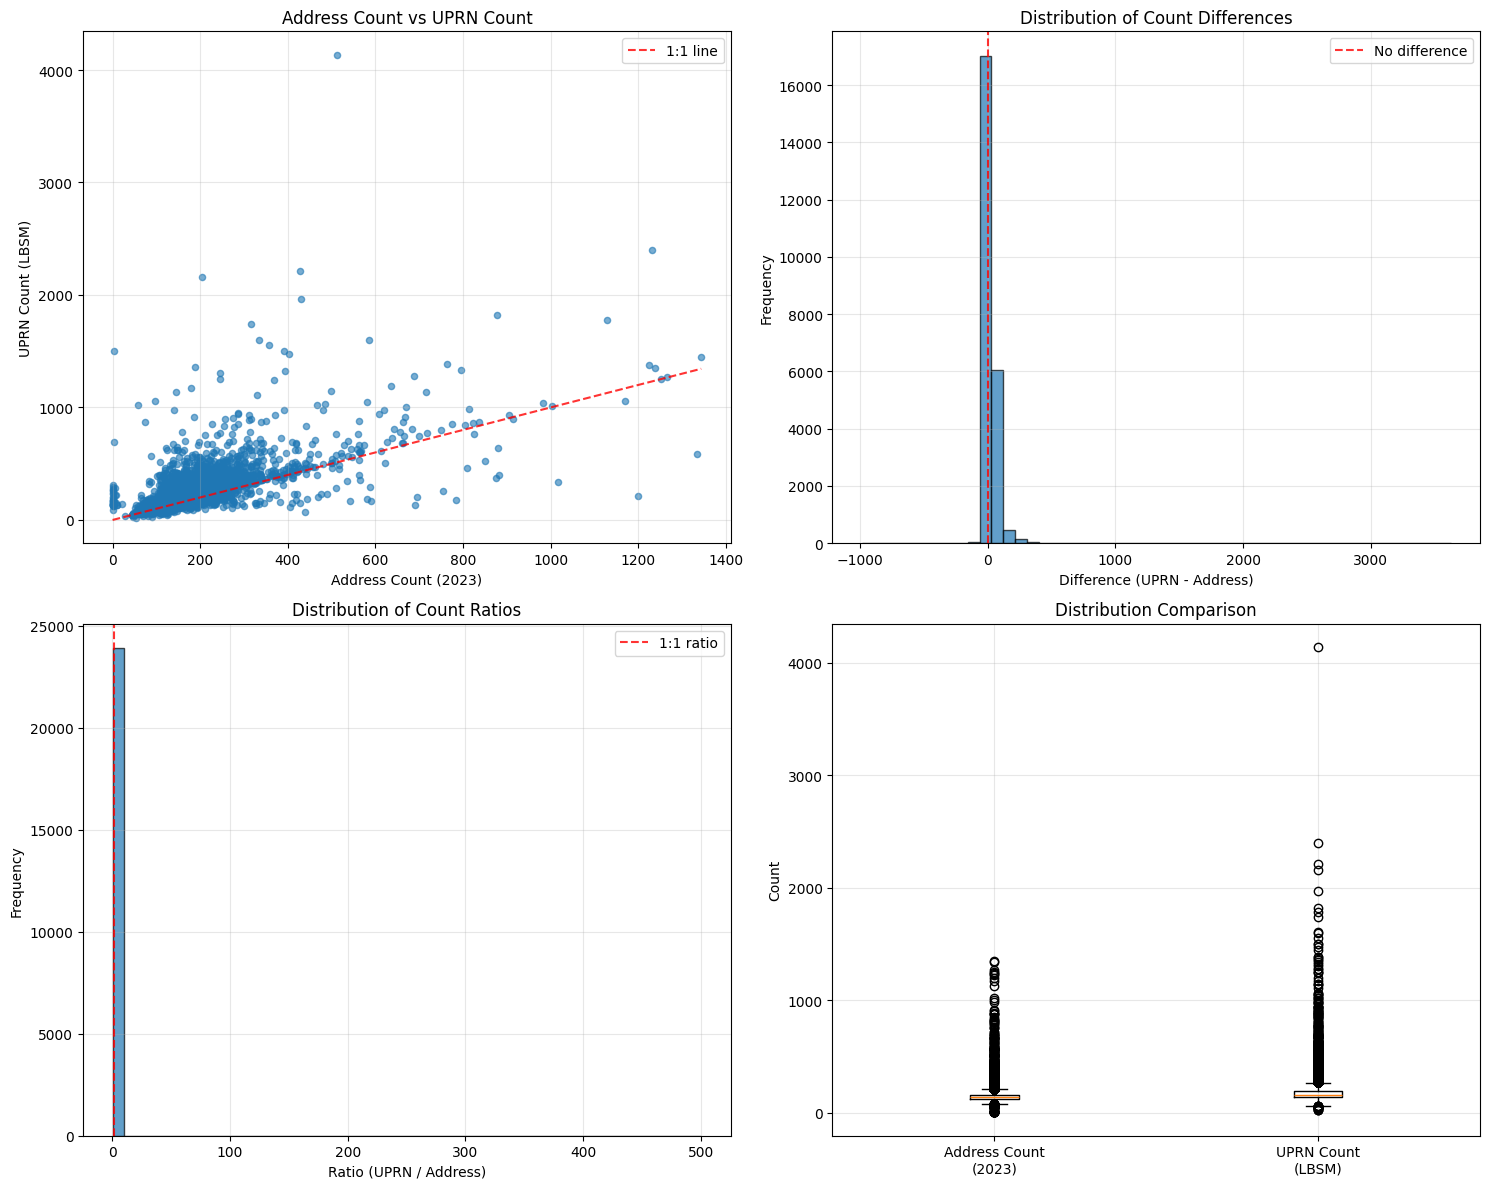

=== SUMMARY CONCLUSIONS ===
• Both datasets have similar column structures (OA code + count)
• Strong correlation: 0.7225 - the counts are highly related
• UPRN counts are generally higher than address counts
• Average difference: 27.6 (UPRN higher)
• Average ratio: 1.380 (UPRN ~24% higher on average)
• 8507 OAs have very similar counts (within 10)
• Data completeness: 90.7% of OAs appear in both datasets


In [48]:
# Create visualizations to compare the two count columns
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot comparing the two counts
axes[0, 0].scatter(merged_comparison['address_count_oa'], merged_comparison['UPRN_count'], 
                   alpha=0.6, s=20)
axes[0, 0].plot([0, merged_comparison['address_count_oa'].max()], 
                [0, merged_comparison['address_count_oa'].max()], 'r--', alpha=0.8, label='1:1 line')
axes[0, 0].set_xlabel('Address Count (2023)')
axes[0, 0].set_ylabel('UPRN Count (LBSM)')
axes[0, 0].set_title('Address Count vs UPRN Count')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Histogram of differences
axes[0, 1].hist(merged_comparison['count_difference'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--', alpha=0.8, label='No difference')
axes[0, 1].set_xlabel('Difference (UPRN - Address)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Count Differences')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Histogram of ratios
axes[1, 0].hist(merged_comparison['ratio_uprn_to_address'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(1, color='red', linestyle='--', alpha=0.8, label='1:1 ratio')
axes[1, 0].set_xlabel('Ratio (UPRN / Address)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Count Ratios')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Box plots comparing both distributions
box_data = [merged_comparison['address_count_oa'], merged_comparison['UPRN_count']]
axes[1, 1].boxplot(box_data, labels=['Address Count\n(2023)', 'UPRN Count\n(LBSM)'])
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Distribution Comparison')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary conclusions
print("=== SUMMARY CONCLUSIONS ===")
print(f"• Both datasets have similar column structures (OA code + count)")
print(f"• Strong correlation: {correlation:.4f} - the counts are highly related")
print(f"• UPRN counts are generally higher than address counts")
print(f"• Average difference: {merged_comparison['count_difference'].mean():.1f} (UPRN higher)")
print(f"• Average ratio: {merged_comparison['ratio_uprn_to_address'].mean():.3f} (UPRN ~24% higher on average)")
print(f"• {len(merged_comparison[abs(merged_comparison['count_difference']) <= 10])} OAs have very similar counts (within 10)")
print(f"• Data completeness: {len(merged_comparison)/max(len(oa_2023_renamed), len(uprn_renamed))*100:.1f}% of OAs appear in both datasets")

Summary of Comparison Between oa_and_ward_address_2023 and uprn_per_oa
Based on the comprehensive analysis, here are the key findings about the similarity between these datasets:


Count Column Comparison:
Strong correlation (0.72): The two count columns are highly related
UPRN counts are systematically higher: Average ratio of 1.38 (UPRN ~38% higher)
Average difference: +27.6 UPRNs per OA compared to address counts
Good agreement: 8,507 OAs (36% of matched records) have counts within 10 of each other
Data Coverage:
High overlap: 90.7% data completeness (23,907 OAs appear in both datasets)
oa_and_ward_address_2023: 26,402 records
uprn_per_oa: 25,133 records
Successfully merged: 23,907 records
Key Differences:
Data sources: Address counts from 2023 vs UPRN counts from LBSM 2017 data
Systematic bias: UPRN counts consistently higher, likely due to:
Different data collection methods
Temporal differences (2017 vs 2023)
Different definitions of what constitutes a "property"

In [49]:
well_matched

,OA_code,address_count_oa,UPRN_count,count_difference,ratio_uprn_to_address
10,E00000022,110,115,5,1.045455
25,E00000042,145,148,3,1.020690
26,E00000043,124,126,2,1.016129
31,E00000050,150,150,0,1.000000
39,E00000059,118,121,3,1.025424
48,E00000069,177,172,-5,0.971751
49,E00000070,154,158,4,1.025974
50,E00000071,119,120,1,1.008403
53,E00000074,104,105,1,1.009615
55,E00000076,111,114,3,1.027027


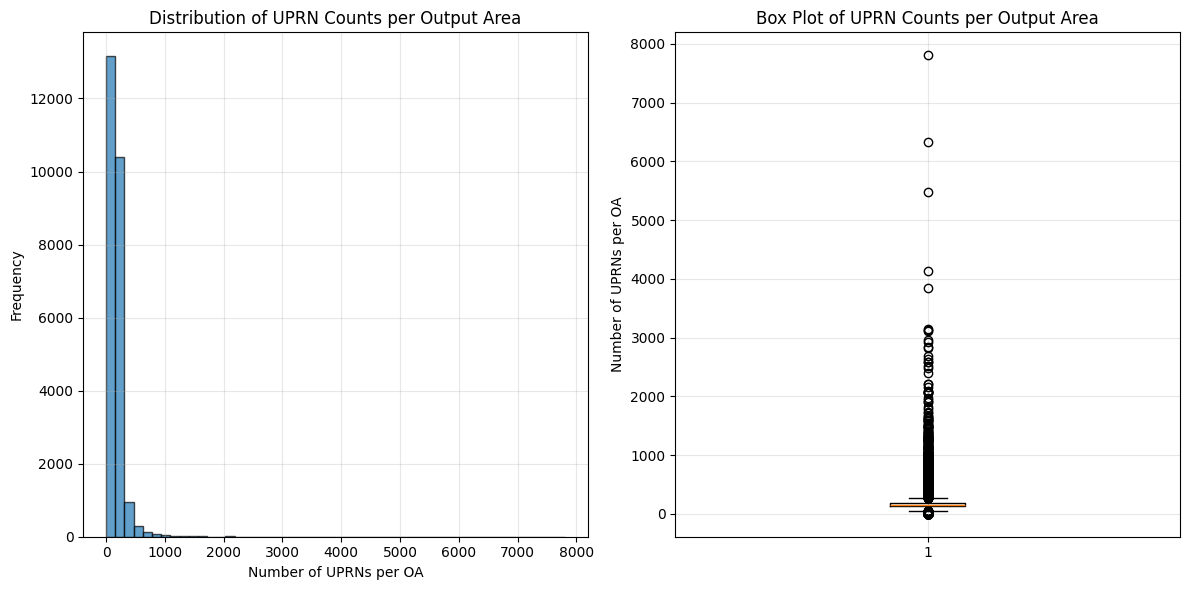


Summary Statistics:
count    25133.000000
mean       187.259181
std        157.244879
min          1.000000
25%        135.000000
50%        155.000000
75%        192.000000
max       7807.000000
Name: UPRN_count, dtype: float64

Top 10 Output Areas with most UPRNs:
              OA  UPRN_count
24634  E00175033        7807
24383  E00174722        6324
22283  E00022974        5482
23561  E00166755        4137
17719  E00018199        3849
5087   E00005197        3153
4633   E00004734        3135
23705  E00167127        3108
23642  E00166856        2963
24354  E00174692        2927

Top 10 Output Areas with fewest UPRNs:
              OA  UPRN_count
8312   E00008515           1
14049  E00014444           1
23391  E00080510           1
23392  E00080521           1
23397  E00089873           1
23402  E00109091           1
23408  E00110551           1
23409  E00110563           1
23412  E00110742           1
23413  E00110774           1


In [50]:
# Show distribution of UPRN counts per OA
import matplotlib.pyplot as plt

# Create a histogram
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(uprn_per_oa['UPRN_count'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of UPRNs per OA')
plt.ylabel('Frequency')
plt.title('Distribution of UPRN Counts per Output Area')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(uprn_per_oa['UPRN_count'])
plt.ylabel('Number of UPRNs per OA')
plt.title('Box Plot of UPRN Counts per Output Area')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show some summary statistics
print("\nSummary Statistics:")
print(uprn_per_oa['UPRN_count'].describe())

# Show OAs with highest and lowest UPRN counts
print(f"\nTop 10 Output Areas with most UPRNs:")
print(uprn_per_oa.nlargest(10, 'UPRN_count'))

print(f"\nTop 10 Output Areas with fewest UPRNs:")
print(uprn_per_oa.nsmallest(10, 'UPRN_count'))

In [51]:
oa_and_ward_address

,OA21CD,LSOA21CD,LSOA21NM,borough,year,address_count_oa,WD24CD,WD24NM,LAD24CD,LAD24NM,LAD24NMW,ObjectId,address_count_ward,oa_yoy_pct_change,ward_yoy_pct_change,oa_address_added,ward_address_added
0,E00000001,E01000001,City of London 001A,City of London,2011,116,E05009288,Aldersgate,E09000001,City of London,NaN,152354,1308,NaN,NaN,116,1308
1,E00000001,E01000001,City of London 001A,City of London,2012,116,E05009288,Aldersgate,E09000001,City of London,NaN,152354,1308,0.000000,0.000000,0,0
2,E00000001,E01000001,City of London 001A,City of London,2013,116,E05009288,Aldersgate,E09000001,City of London,NaN,152354,1308,0.000000,0.000000,0,0
3,E00000001,E01000001,City of London 001A,City of London,2014,116,E05009288,Aldersgate,E09000001,City of London,NaN,152354,1311,0.000000,0.229358,0,3
4,E00000001,E01000001,City of London 001A,City of London,2015,116,E05009288,Aldersgate,E09000001,City of London,NaN,152354,1311,0.000000,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367556,E00190469,E01035709,Camden 022G,Camden,2020,108,E05013669,St Pancras & Somers Town,E09000007,Camden,NaN,157320,6678,0.000000,0.000000,0,0
367557,E00190469,E01035709,Camden 022G,Camden,2021,108,E05013669,St Pancras & Somers Town,E09000007,Camden,NaN,157320,6756,0.000000,1.168014,0,78
367558,E00190469,E01035709,Camden 022G,Camden,2022,108,E05013669,St Pancras & Somers Town,E09000007,Camden,NaN,157320,6895,0.000000,2.057430,0,139
367559,E00190469,E01035709,Camden 022G,Camden,2023,108,E05013669,St Pancras & Somers Town,E09000007,Camden,NaN,157320,6929,0.000000,0.493111,0,34
